# NDVI over time (AOI run)

This notebook reads an ingestion run folder (e.g. `data/aoi_demo_01/`), loads:
- `run_metadata.json`
- `indices_timeseries.csv`

…and plots NDVI mean (and optionally p95) over time.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

# Point this to your AOI output directory
RUN_DIR = Path.cwd().parent / "data" / "aoi_demo_01"

csv_path = RUN_DIR / 'indices_timeseries.csv'
meta_path = RUN_DIR / 'run_metadata.json'

assert csv_path.exists(), f'Missing {csv_path}'
assert meta_path.exists(), f'Missing {meta_path}'

metadata = json.loads(meta_path.read_text(encoding='utf-8'))
metadata


{'aoi_id': 'aoi_demo_01',
 'bbox': [30.9903, 30.594356, 31.013848, 30.616635],
 'created_at': '2026-02-15T14:48:19.112642+00:00',
 'end_date': '2026-01-01',
 'fingerprint': 'a0d65bc1f9a0df0192473e1aebe8132f3e25c6f5a825ee46a89f0c6f84d08786',
 'invalid_scl_classes': [0, 1, 3, 7, 8, 9, 10, 11],
 'max_cloud': 5.0,
 'mode': 'download-chips+stats',
 'notes': 'Canonical chips dataset + global JSON index caching (skip if chips exist for same fingerprint).',
 'outputs': {'chips_root': 'data/aoi_demo_01/chips',
  'csv': 'data/aoi_demo_01/indices_timeseries.csv',
  'scenes_index': 'data/aoi_demo_01/scenes_index.json'},
 'scene_count': 3,
 'start_date': '2025-08-01'}

In [2]:
df = pd.read_csv(csv_path)

# Parse timestamps, sort
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
df = df.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)

df.head()


,item_id,timestamp,mgrs_tile,eo_cloud_cover,valid_fraction,ndvi_mean,ndvi_p95,evi_mean,evi_p95,ndmi_mean,ndmi_p95,ndwi_mean,ndwi_p95,mndwi_mean,mndwi_p95
0,S2C_MSIL2A_20250803T083711_R064_T36RUU_2025080...,2025-08-03 08:37:11.025000+00:00,unknown,1.788243,0.793317,0.399680,0.562411,0.441732,0.654613,0.155691,0.287267,-0.389283,-0.155419,-0.252876,-0.149273
1,S2C_MSIL2A_20250803T083711_R064_T36RTU_2025080...,2025-08-03 08:37:11.025000+00:00,unknown,4.067597,0.794538,0.402987,0.561673,0.442613,0.651746,0.154504,0.285438,-0.392071,-0.163689,-0.256919,-0.157697
2,S2A_MSIL2A_20250812T083521_R021_T36RUU_2025081...,2025-08-12 08:35:21.024000+00:00,unknown,1.159379,0.585914,0.403271,0.567946,0.403545,0.598608,0.103966,0.209843,-0.402968,-0.192381,-0.315780,-0.240906


In [3]:
# Basic sanity checks / quick summary
summary = {
    'rows': int(len(df)),
    'start': df['timestamp'].min(),
    'end': df['timestamp'].max(),
    'mean_valid_fraction': float(df['valid_fraction'].mean()) if len(df) else None,
    'cloud_cover_min': float(df['eo_cloud_cover'].min()) if len(df) else None,
    'cloud_cover_max': float(df['eo_cloud_cover'].max()) if len(df) else None,
}
summary


{'rows': 3,
 'start': Timestamp('2025-08-03 08:37:11.025000+0000', tz='UTC'),
 'end': Timestamp('2025-08-12 08:35:21.024000+0000', tz='UTC'),
 'mean_valid_fraction': 0.7245897712300874,
 'cloud_cover_min': 1.159379,
 'cloud_cover_max': 4.067597}

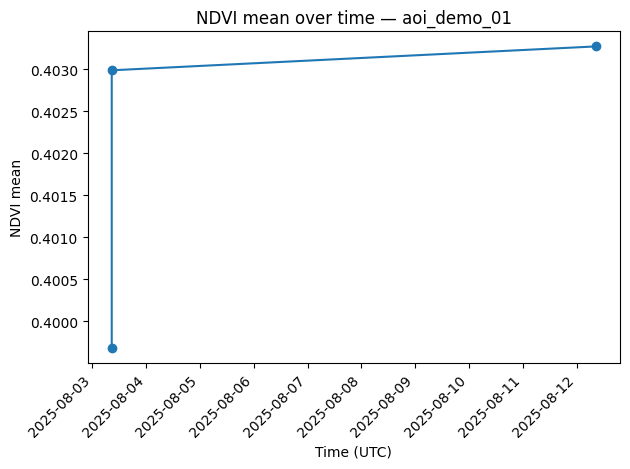

In [4]:
# Plot NDVI mean over time
plt.figure()
plt.plot(df['timestamp'], df['ndvi_mean'], marker='o')
plt.title(f"NDVI mean over time — {metadata.get('aoi_id','(unknown AOI)')}")
plt.xlabel('Time (UTC)')
plt.ylabel('NDVI mean')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


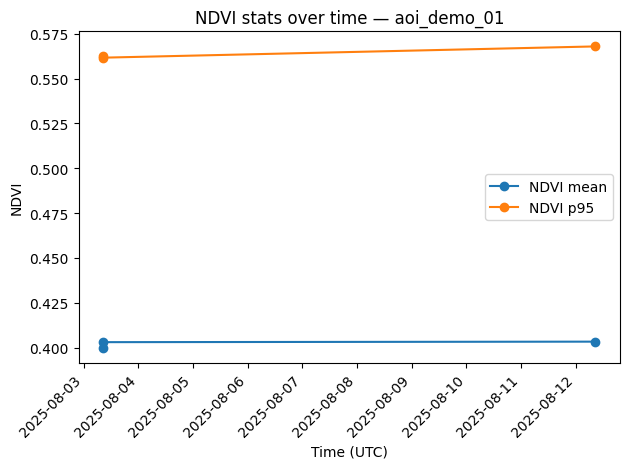

In [5]:
# Optional: plot NDVI p95 too
plt.figure()
plt.plot(df['timestamp'], df['ndvi_mean'], marker='o', label='NDVI mean')
plt.plot(df['timestamp'], df['ndvi_p95'], marker='o', label='NDVI p95')
plt.title(f"NDVI stats over time — {metadata.get('aoi_id','(unknown AOI)')}")
plt.xlabel('Time (UTC)')
plt.ylabel('NDVI')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


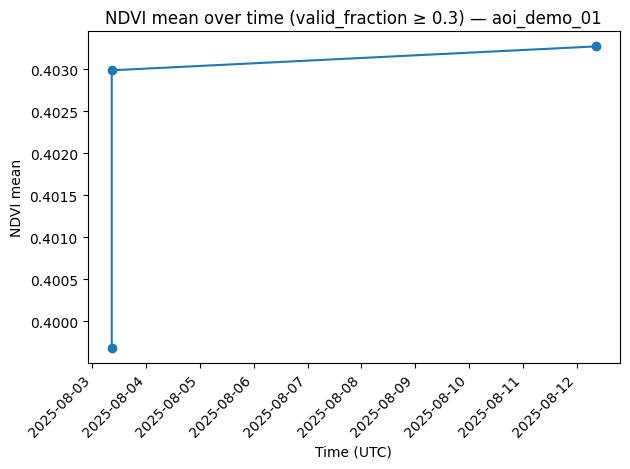

(3, 3)

In [6]:
# Optional: a quick filter helper (e.g., require some valid_fraction threshold)
MIN_VALID_FRACTION = 0.3
filtered = df[df['valid_fraction'] >= MIN_VALID_FRACTION].copy()

plt.figure()
plt.plot(filtered['timestamp'], filtered['ndvi_mean'], marker='o')
plt.title(
    f"NDVI mean over time (valid_fraction ≥ {MIN_VALID_FRACTION}) — {metadata.get('aoi_id','')}"
)
plt.xlabel('Time (UTC)')
plt.ylabel('NDVI mean')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

len(filtered), len(df)
